x       6.591631
y       0.267517
dx      8.305990
dy     -2.971627
time    0.701000
Name: 701, dtype: float64
x       6.408229
y       0.330752
dx      8.366986
dy     -2.776838
time    0.679000
Name: 679, dtype: float64
Time in window: 0.0220s
14.222222222222221


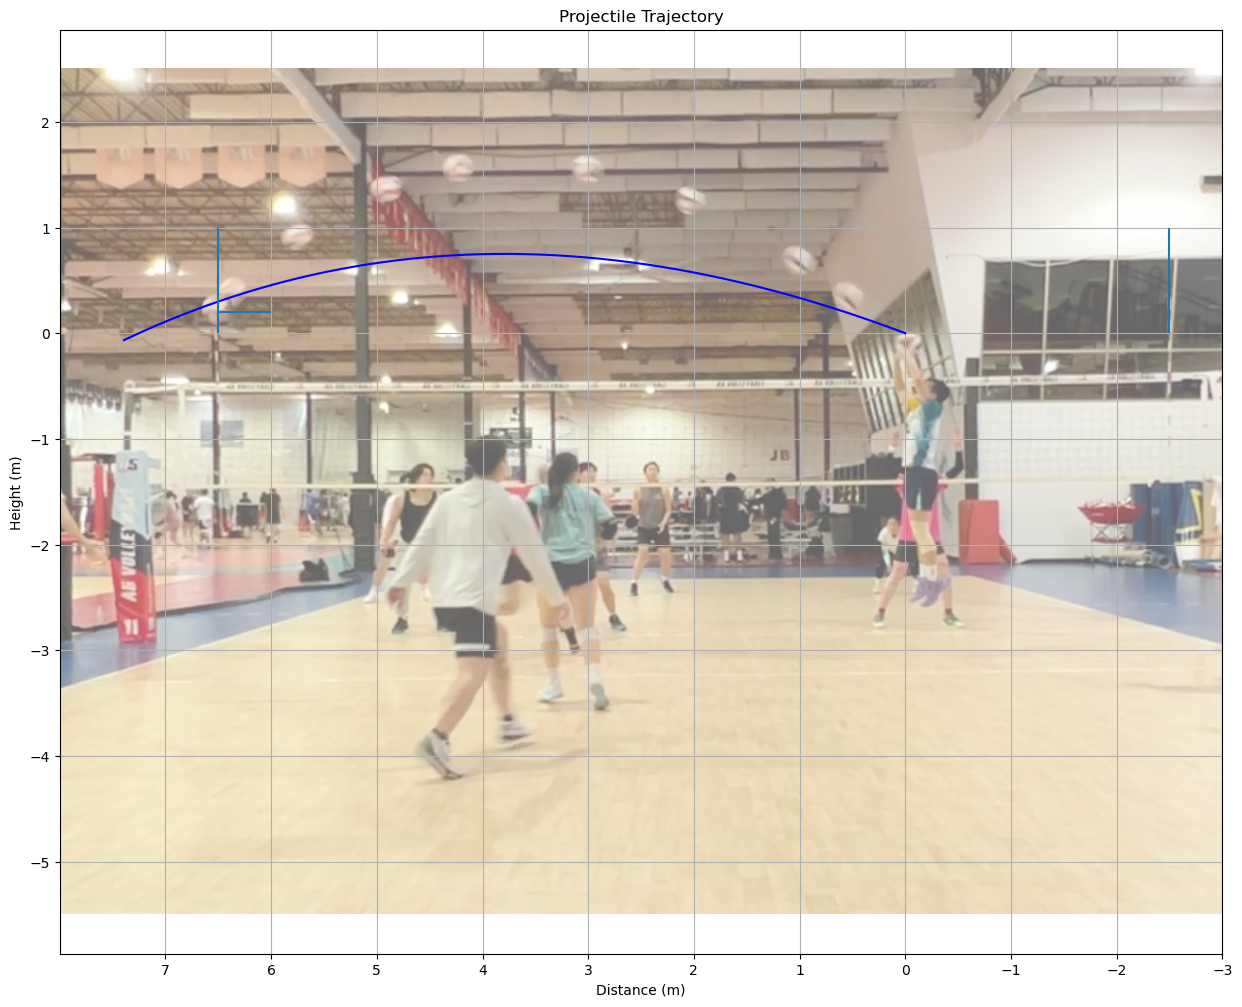

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from scipy.optimize import minimize
import pandas as pd

class ProjectileMotion:
    def __init__(self, 
                 mass=0.27,          # kg (volleyball mass)
                 diameter=0.21,       # m (volleyball diameter)
                 drag_coefficient=0.88, # dimensionless 0.48
                 air_density=1.225):  # kg/m³ (at sea level, 15°C)
        
        self.mass = mass
        self.diameter = diameter
        self.area = np.pi * (diameter/2)**2  # cross-sectional area
        self.drag_coefficient = drag_coefficient
        self.air_density = air_density
        self.gravity = 9.81  # m/s²
        
    def drag_force(self, velocity):
        """Calculate drag force using F = 1/2 * ρ * v² * Cd * A"""
        velocity_magnitude = np.linalg.norm(velocity)
        if velocity_magnitude == 0:
            return np.zeros_like(velocity)
        
        drag_magnitude = (0.5 * self.air_density * velocity_magnitude**2 * 
                         self.drag_coefficient * self.area)
        
        # Drag force acts in opposite direction of velocity
        return -drag_magnitude * velocity / velocity_magnitude
    
    def derivatives(self, state, t):
        """Calculate derivatives for position and velocity"""
        # state = [x, y, vx, vy]
        vx, vy = state[2], state[3]
        velocity = np.array([vx, vy])
        
        # Calculate drag force
        drag_force = self.drag_force(velocity)
        
        # Acceleration components (F = ma)
        ax = drag_force[0] / self.mass
        ay = drag_force[1] / self.mass - self.gravity
        
        return [vx, vy, ax, ay]
    
    def simulate(self, initial_velocity, angle_degrees, time_span, dt=0.001):
        """
        Simulate projectile motion
        
        Parameters:
        - initial_velocity: speed in m/s
        - angle_degrees: launch angle in degrees
        - time_span: simulation duration in seconds
        - dt: time step in seconds
        """
        # Convert angle to radians
        angle = np.deg2rad(angle_degrees)
        
        # Initial conditions [x, y, vx, vy]
        initial_state = [0, 0,
                        initial_velocity * np.cos(angle),
                        initial_velocity * np.sin(angle)]
        
        # Time points
        t = np.arange(0, time_span, dt)
        
        # Solve ODE
        solution = odeint(self.derivatives, initial_state, t)
        
        return t, solution
    
    def objective(self, params, x_target, y_target, time_span, dt=0.01):
        initial_velocity, angle_degrees = params
        angle = np.deg2rad(angle_degrees)
        
        x1, y1 = x_target, y_target

        initial_state = [0, 0,
                        initial_velocity * np.cos(angle),
                        initial_velocity * np.sin(angle)]
        
        t = np.arange(0, time_span, dt)

        solution = odeint(self.derivatives, initial_state, t)

        xT, yT = solution[-1][0], solution[-1][1]
        return (xT - x1)**2 + (yT - y1)**2  # squared distance error


    def find_objective(self, v0_guess, x_target, y_target, t):
        result = minimize(self.objective,
                        v0_guess,
                        args=(x_target, y_target, t),
                        method='SLSQP')
        return result

    def plot_trajectory(self, t, solution, show_velocity=True):
        """Plot the trajectory and optionally show velocity vectors"""
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))
        # ax1 = plt.subplot()
        
        # Trajectory plot
        ax1.plot(solution[:, 0], solution[:, 1], 'b*', label='Trajectory')
        ax1.set_xlabel('Distance (m)')
        ax1.set_ylabel('Height (m)')
        ax1.set_title('Projectile Trajectory')
        ax1.grid(True)
        ax1.axis('equal')
        ax1.set_xlim([-3,8])
        ax1.set_xticks(range(-3, 8))
        ax1.vlines([-2.5, 6.5], 0, 1)
        ax1.hlines([0.2], 6, 6.5)
        ax1.invert_xaxis()
        img = plt.imread("Volleyball_Shoot_Processed.png")

        img_height = 8
        img_width = img_height*16/9

        img_pos = [-5, -5.5]
        print(img_width)

        ax1.imshow(img, extent=[img_pos[0]+img_width, img_pos[0], img_pos[1], img_pos[1]+img_height], alpha=0.6)
        
        # if show_velocity:
        #     # Plot velocity vectors at regular intervals
        #     skip = len(t) // 20  # Show ~20 vectors
        #     for i in range(0, len(t), skip):
        #         ax1.quiver(solution[i, 0], solution[i, 1],
        #                   solution[i, 2], solution[i, 3],
        #                   angles='xy', scale_units='xy', scale=50,
        #                   color='r', alpha=0.3)
        
        # Velocity components plot
        ax2.plot(solution[:, 0], solution[:, 2], 'r-', label='Horizontal velocity')
        ax2.plot(solution[:, 0], solution[:, 3], 'g-', label='Vertical velocity')
        ax2.plot(solution[:, 0], (abs(solution[:, 2])**2 + abs(solution[:, 3])**2)**0.5, 'b-', label='ABS velocity')
        ax2.set_xlabel('POS (s)')
        ax2.set_ylabel('Velocity (m/s)')
        ax2.set_title('Velocity Components')
        ax2.grid(True)
        ax2.legend()
        
        plt.tight_layout()
        # return fig# , (ax1, ax2)
        # return ax1


    def in_hitting_window(self, row, target):
        # target = np.array([6.5, 0.3])
        # target = args[0]
        # print(row)
        x = row["x"]
        y = row["y"]
        # pos = np.array(row['x', 'y'])
        pos = np.array([x, y])
        # print(f"pos {pos}")
        # print(f"target {target}")
        # print(np.linalg.norm(pos - target))
        # print(np.linalg.norm(pos - target))
        # print(np.linalg.norm(pos - target) < hitting_radius)
        # print(pos)
        # return None
        if np.linalg.norm(pos - target) < hitting_radius:
            return True
        return False

# Example usage
if __name__ == "__main__":
    # Create projectile instance (using volleyball properties)
    proj = ProjectileMotion(drag_coefficient = 0.48)
    
    # Cd = 0.48
    # rho = 1.225
    # A = 0.0346
    # m = 0.27

    time_span = 0.7 #108, 1.4
    time_past_span = 0.1

    target = np.array([6.5, 0.3])
    hitting_radius = 0.1 # meters

    result = proj.find_objective([10,40], target[0], target[1], time_span)
    # print(result)
    # print("end result")

    initial_velocity, angle = result.x[0], result.x[1]
    # Run simulation
    t, solution = proj.simulate(initial_velocity, angle, time_span + time_past_span)

    df_sol = pd.DataFrame.from_dict(dict(zip(["x", "y", "dx", "dy"], solution.T)), orient='columns')
    df_sol["time"] = t
    # print(df_sol)
    # df_sol_window = df_sol[df_sol.apply(proj.in_hitting_window, axis=1, args=target)]
    df_sol_window = df_sol[df_sol.apply(proj.in_hitting_window, axis=1, args=(target,))]
    # print(df_sol_window)
    max_t = df_sol_window.loc[df_sol_window['time'].idxmax()]
    min_t = df_sol_window.loc[df_sol_window['time'].idxmin()]
    print(max_t)
    print(min_t)
    time_in_window = max_t['time'] - min_t['time']
    print(f"Time in window: {time_in_window:.4f}s")

    # proj.plot_trajectory(t, solution, show_velocity=True)
    fig, (ax1) = plt.subplots(1, 1, figsize=(15, 12))
    # ax1 = plt.subplot()
    
    # Trajectory plot
    ax1.plot(solution[:, 0], solution[:, 1], 'b-', label='Trajectory')
    ax1.set_xlabel('Distance (m)')
    ax1.set_ylabel('Height (m)')
    ax1.set_title('Projectile Trajectory')
    ax1.grid(True)
    ax1.axis('equal')
    ax1.set_xlim([-3,8])
    ax1.set_xticks(range(-3, 8))
    ax1.vlines([-2.5, 6.5], 0, 1)
    ax1.hlines([0.2], 6, 6.5)
    ax1.invert_xaxis()
    img = plt.imread("Volleyball_Shoot_Processed.png")

    img_height = 8
    img_width = img_height*16/9

    img_pos = [-5, -5.5]
    print(img_width)

    ax1.imshow(img, extent=[img_pos[0]+img_width, img_pos[0], img_pos[1], img_pos[1]+img_height], alpha=0.6)
    

